# Model Training & Experimentation

This notebook develops and compares forecasting models for daily item-store demand.

The modelling approach follows a time-series workflow:
1. establish simple historical baselines,
2. train a LightGBM model using calendar, price, event, item/store, lag, and rolling-demand features,
3. test a small number of targeted improvements,
4. select the final configuration using the validation period only,
5. save the selected model for final evaluation in the next notebook.

The goal is not to try every possible algorithm. Each experiment is included only when it answers a specific modelling question and can be compared fairly against the existing model.


## Modelling Strategy

The target is daily `sales` for each **item-store combination**.

Because this is a forecasting problem, the data is split chronologically rather than randomly. The model is trained on earlier dates, validated on a later block of dates, and the final test period is kept untouched for `03_model_evaluation.ipynb`.

We use **MAE as the primary metric** because it is directly interpretable as the average absolute forecasting error in units sold. RMSE is retained as a secondary metric because it gives greater weight to large mistakes.

The main model is LightGBM with an L1 regression objective. This gives us a strong tabular model while remaining practical for a dataset of this size.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

pd.set_option("display.max_columns", None)


## Load the Processed Modelling Dataset

The raw-data reshaping and feature engineering are handled in `01_data_processing.ipynb`. This notebook starts from the processed modelling table so that training experiments remain focused on model behaviour rather than repeating preprocessing.

The processed dataset contains one row per item-store-day observation.


In [12]:
sales_model = pd.read_parquet(
    "../data/processed_sales.parquet"
)

print("Shape:", sales_model.shape)
display(sales_model.head())

Shape: (58327370, 24)


,item_id,dept_id,cat_id,store_id,state_id,sales,date,weekday,wday,month,year,snap,sell_price,price_missing,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_28,rolling_mean_14,has_event,event_type,event_name
0,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2,2011-02-26,Saturday,1.0,2.0,2011.0,0.0,2.0,0.0,4.0,1.0,3.0,3.0,1.857143,1.392857,1.642857,0.0,None,None
1,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2,2011-02-27,Sunday,2.0,2.0,2011.0,0.0,2.0,0.0,2.0,2.0,0.0,0.0,2.000000,1.357143,1.571429,0.0,None,None
2,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,0,2011-02-28,Monday,3.0,2.0,2011.0,0.0,2.0,0.0,2.0,0.0,2.0,0.0,2.000000,1.428571,1.714286,0.0,None,None
3,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,2,2011-03-01,Tuesday,4.0,3.0,2011.0,1.0,2.0,0.0,0.0,2.0,1.0,1.0,2.000000,1.428571,1.571429,0.0,None,None
4,FOODS_1_001,FOODS_1,FOODS,CA_1,CA,1,2011-03-02,Wednesday,5.0,3.0,2011.0,1.0,2.0,0.0,2.0,2.0,2.0,4.0,2.000000,1.464286,1.642857,0.0,None,None


## Confirm the Forecasting Window

The project uses all available historical days rather than restricting training to a single year. This preserves long-term trends and recurring seasonal patterns while still using a genuinely future validation/test period.

The final dates are reserved for evaluation; no test observations are used for model selection.


In [ ]:
print("Date range:")
print(sales_model["date"].min(), "→", sales_model["date"].max())

print("Rows:", len(sales_model))
print("Unique item-store series:",
      sales_model[["item_id", "store_id"]].drop_duplicates().shape[0])


## Chronological Train / Validation / Test Split

We use a forward-in-time split:

- **Training:** through 2016-03-24
- **Validation:** 2016-03-25 to 2016-04-24
- **Test:** 2016-04-25 to 2016-05-22

This mirrors how the model will be used in practice: learn from the past, choose the model on the next period, and finally report performance on a later unseen period.

The test set is intentionally defined here for bookkeeping, but it is **not evaluated in this notebook**. Final test evaluation is performed once in `03_model_evaluation.ipynb`.


In [14]:
train_mask = sales_model["date"] <= "2016-03-24"

validation_mask = (
    (sales_model["date"] >= "2016-03-25") &
    (sales_model["date"] <= "2016-04-24")
)

test_mask = (
    (sales_model["date"] >= "2016-04-25") &
    (sales_model["date"] <= "2016-05-22")
)

print("Train rows:", train_mask.sum())
print("Validation rows:", validation_mask.sum())
print("Test rows:", test_mask.sum())

Train rows: 56528460
Validation rows: 945190
Test rows: 853720


## Baseline Models

Before using machine learning, we need a benchmark.

A **Lag-1 baseline** predicts today's demand using the same item's/store's demand from the previous day. This is a strong and intuitive benchmark for a short-term demand series.

A **Lag-7 baseline** uses demand from the same day of the previous week and gives us a simple way to test whether weekly seasonality is more useful than immediate history.


In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

validation_actual = sales_model.loc[validation_mask, "sales"]
validation_pred_lag1 = sales_model.loc[validation_mask, "lag_1"]

lag1_mae = mean_absolute_error(
    validation_actual,
    validation_pred_lag1
)

lag1_rmse = np.sqrt(
    mean_squared_error(
        validation_actual,
        validation_pred_lag1
    )
)

print("Lag-1 Baseline")
print("MAE :", lag1_mae)
print("RMSE:", lag1_rmse)

Lag-1 Baseline
MAE : 1.1863837242126465
RMSE: 2.6129147396608756


In [16]:
validation_pred_lag7 = sales_model.loc[validation_mask, "lag_7"]

lag7_mae = mean_absolute_error(
    validation_actual,
    validation_pred_lag7
)

lag7_rmse = np.sqrt(
    mean_squared_error(
        validation_actual,
        validation_pred_lag7
    )
)

print("Lag-7 Baseline")
print("MAE :", lag7_mae)
print("RMSE:", lag7_rmse)

Lag-7 Baseline
MAE : 1.2154878377914429
RMSE: 2.696417717383995


## Feature Groups

The feature set combines several sources of information:

- **Entity features:** item, department, category, store, and state
- **Calendar features:** weekday, month, year
- **Event and promotion features:** event indicators/types/names and SNAP
- **Price features:** sell price plus a missing-price indicator
- **Historical demand:** lagged sales and rolling means

The lag and rolling features are especially important because demand has strong temporal dependence. They are created using past observations only, so the model does not get access to the target it is trying to predict.


In [17]:
categorical_cols = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",
    "event_type",
    "event_name"
]

for col in categorical_cols:
    print(col, "→", sales_model[col].dtype)

item_id → category
dept_id → category
cat_id → category
store_id → category
state_id → category
event_type → category
event_name → category


In [ ]:
feature_cols = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",

    "wday",
    "month",
    "year",

    "has_event",
    "event_type",
    "event_name",
    "snap",

    "sell_price",
    "price_missing",

    # Established lag and rolling-demand features
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28"
]

target_col = "sales"

required_features = set(feature_cols)
missing_features = required_features - set(sales_model.columns)

if missing_features:
    raise ValueError(
        f"Processed dataset is missing required model features: {sorted(missing_features)}"
    )

print("Number of features:", len(feature_cols))


### Prepare Training and Validation Matrices

At this point the data has already been engineered. We simply select the feature columns and target for the two periods used during model development.

The test set is deliberately not touched here.


In [19]:
X_train = sales_model.loc[train_mask, feature_cols]
y_train = sales_model.loc[train_mask, target_col]

X_validation = sales_model.loc[validation_mask, feature_cols]
y_validation = sales_model.loc[validation_mask, target_col]

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)

X_train: (56528460, 21)
X_validation: (945190, 21)


## Baseline LightGBM Model

The first machine-learning model uses a 64-leaf LightGBM regressor with an L1 objective.

Why these choices?

- `num_leaves=64` gives the model enough flexibility for a high-cardinality retail dataset without starting with an unnecessarily complex model.
- `learning_rate=0.05` allows gradual learning.
- `colsample_bytree=0.8` adds some randomness and helps reduce reliance on any one subset of features.
- **Early stopping** monitors the validation set and stops once additional trees stop improving it.

The validation set is used for early stopping and model comparison; the test set remains untouched.


In [20]:
import lightgbm as lgb

model = lgb.LGBMRegressor(
    objective="regression_l1",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

In [21]:
model.fit(
    X_train,
    y_train,
    categorical_feature=categorical_cols,
    eval_set=[(X_validation, y_validation)],
    eval_metric=["l1", "rmse"],
    callbacks=[
        lgb.early_stopping(30),
        lgb.log_evaluation(25)
    ]
)

/opt/anaconda3/envs/deeplearning/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.766791 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4479
[LightGBM] [Info] Number of data points in the train set: 56528460, number of used features: 21
Training until validation scores don't improve for 30 rounds
[25]	valid_0's l1: 0.98269	valid_0's rmse: 2.6785
[50]	valid_0's l1: 0.910474	valid_0's rmse: 2.22746
[75]	valid_0's l1: 0.896983	valid_0's rmse: 2.10683
[100]	valid_0's l1: 0.893304	valid_0's rmse: 2.06811
[125]	valid_0's l1: 0.891918	valid_0's rmse: 2.05234
[150]	valid_0's l1: 0.891252	valid_0's rmse: 2.04371
[175]	valid_0's l1: 0.890976	valid_0's 

,num_leaves,64
,learning_rate,0.05
,n_estimators,500
,objective,'regression_l1'
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None


## Feature Importance

Feature importance is used here as an interpretability aid rather than as proof of causation. A high importance value means the model relied heavily on that feature while building its trees; it does not mean that feature independently causes demand.

This first importance plot also helps us understand whether the model is leaning on sensible demand-history signals.


In [22]:
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": model.feature_importances_
}).sort_values(
    "importance",
    ascending=False
)

display(feature_importance)

,feature,importance
0,item_id,6284
20,rolling_mean_28,4945
18,rolling_mean_7,3508
5,wday,2338
19,rolling_mean_14,2131
1,dept_id,1502
14,lag_1,1176
10,event_name,891
12,sell_price,784
11,snap,658


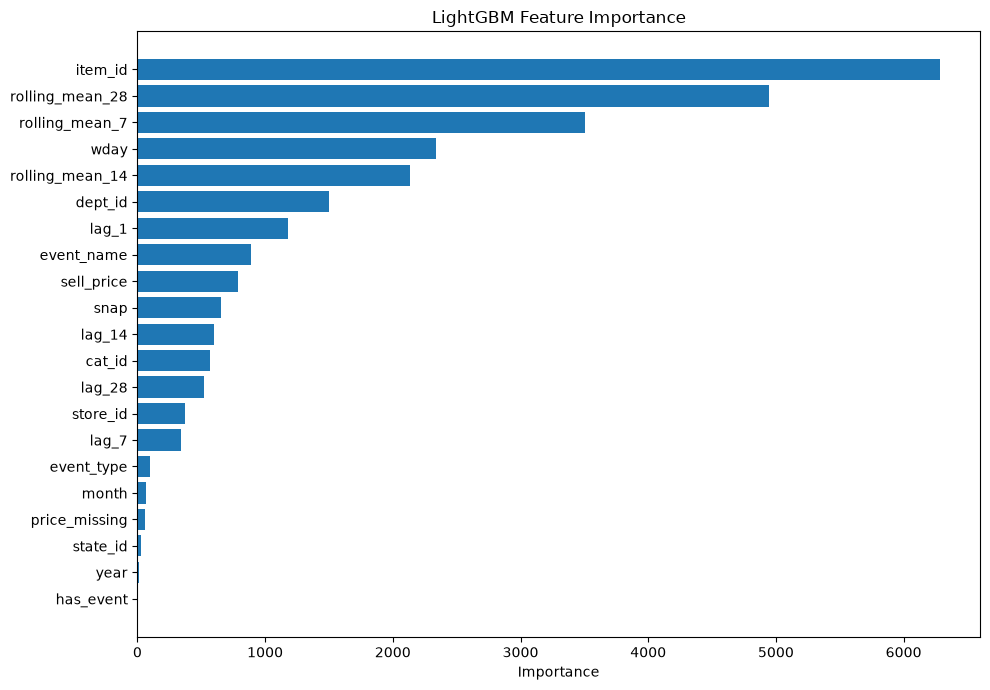

In [23]:
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.gca().invert_yaxis()

plt.title("LightGBM Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

## Baseline LightGBM Validation Performance

We now evaluate the first LightGBM model on the validation period.

This becomes the main reference point for the experiments that follow.


In [25]:
# Generate validation predictions
validation_pred = model.predict(X_validation)

# Calculate metrics
lightgbm_mae = mean_absolute_error(
    y_validation,
    validation_pred
)

lightgbm_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        validation_pred
    )
)

print("LightGBM Validation Performance")
print("--------------------------------")
print(f"MAE : {lightgbm_mae:.4f}")
print(f"RMSE: {lightgbm_rmse:.4f}")

LightGBM Validation Performance
--------------------------------
MAE : 0.8898
RMSE: 2.0350


In [26]:
improvement = (
    (lag1_mae - lightgbm_mae) / lag1_mae
) * 100

print(f"MAE improvement over Lag-1: {improvement:.2f}%")

MAE improvement over Lag-1: 25.00%


## Sanity Check: Negative Predictions

Sales cannot be negative, but an unconstrained regression model can produce a small negative prediction.

Rather than silently correcting this, we first measure how often it happens. We then test whether clipping predictions at zero actually improves validation performance.


In [27]:
print("Minimum prediction:", validation_pred.min())
print("Maximum prediction:", validation_pred.max())
print("Negative predictions:", (validation_pred < 0).sum())

Minimum prediction: -0.5987075420191037
Maximum prediction: 127.32054419849544
Negative predictions: 25034


### Testing Non-negative Clipping

Clipping is a simple business constraint: replace any negative prediction with zero.

We keep it only if it improves our validation metrics. This is preferable to assuming that a seemingly sensible post-processing step must help.


In [28]:
validation_pred_clipped = np.maximum(validation_pred, 0)

clipped_mae = mean_absolute_error(
    y_validation,
    validation_pred_clipped
)

clipped_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        validation_pred_clipped
    )
)

print("Clipped LightGBM")
print("----------------")
print(f"MAE : {clipped_mae:.4f}")
print(f"RMSE: {clipped_rmse:.4f}")

Clipped LightGBM
----------------
MAE : 0.8897
RMSE: 2.0349


## Error Analysis: Zero vs Positive Demand

The dataset is highly sparse, so overall MAE can hide an important distinction: predicting a zero-sales observation accurately is easier than predicting a higher-demand observation accurately.

We therefore calculate MAE separately for zero-demand and positive-demand observations. This diagnostic later helps explain the model's behaviour on the final test set.


In [29]:
zero_mask = y_validation == 0
positive_mask = y_validation > 0

print("Validation observations")
print("-----------------------")
print("Zero-sales:", zero_mask.sum())
print("Positive-sales:", positive_mask.sum())

print("\nMAE")
print("Zero-sales:", mean_absolute_error(
    y_validation[zero_mask],
    validation_pred[zero_mask]
))

print("Positive-sales:", mean_absolute_error(
    y_validation[positive_mask],
    validation_pred[positive_mask]
))

Validation observations
-----------------------
Zero-sales: 530270
Positive-sales: 414920

MAE
Zero-sales: 0.23675526618086093
Positive-sales: 1.7243785730006185


## Validation Comparison

This table consolidates the baseline models and the first LightGBM model.

At this stage, the objective is not merely to obtain a low score, but to establish whether machine learning provides a meaningful improvement over simple historical rules.


In [30]:
comparison = pd.DataFrame({
    "Model": [
        "Lag-1",
        "Lag-7",
        "LightGBM",
        "LightGBM (clipped)"
    ],
    "MAE": [
        lag1_mae,
        lag7_mae,
        lightgbm_mae,
        clipped_mae
    ],
    "RMSE": [
        lag1_rmse,
        lag7_rmse,
        lightgbm_rmse,
        clipped_rmse
    ]
})

display(comparison)

,Model,MAE,RMSE
0,Lag-1,1.186384,2.612915
1,Lag-7,1.215488,2.696418
2,LightGBM,0.889793,2.034958
3,LightGBM (clipped),0.889695,2.034921


## Error by Demand Level

Because demand is strongly skewed, MAE should also be viewed across demand ranges.

If errors rise sharply as actual sales increase, a low overall MAE may partly reflect the large number of low-demand/zero-demand observations.


In [31]:
bins = [-1, 0, 1, 5, 10, 20, 50, 100, np.inf]
labels = [
    "0",
    "1",
    "2-5",
    "6-10",
    "11-20",
    "21-50",
    "51-100",
    "100+"
]

error_analysis = pd.DataFrame({
    "actual": y_validation.values,
    "prediction": validation_pred
})

error_analysis["abs_error"] = (
    error_analysis["actual"] -
    error_analysis["prediction"]
).abs()

error_analysis["sales_range"] = pd.cut(
    error_analysis["actual"],
    bins=bins,
    labels=labels
)

error_by_range = (
    error_analysis
    .groupby("sales_range", observed=False)["abs_error"]
    .agg(["count", "mean"])
)

display(error_by_range)

,count,mean
sales_range,,
0,530270,0.236755
1,180701,0.775585
2-5,181277,1.706946
6-10,33913,3.517622
11-20,13561,5.918758
21-50,4772,10.558566
51-100,632,20.750077
100+,64,44.425381


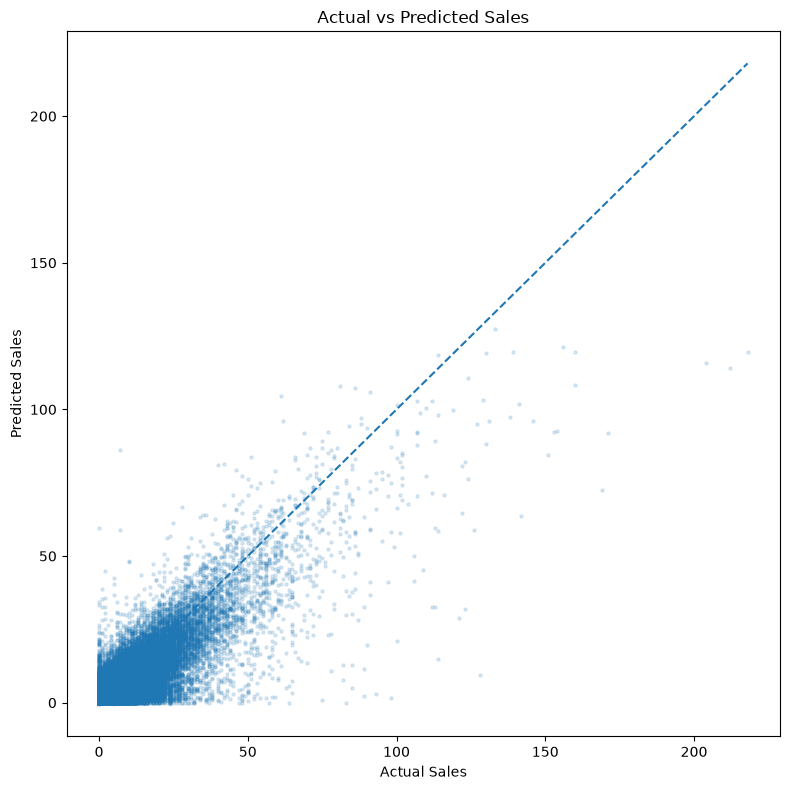

In [32]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_validation,
    validation_pred,
    alpha=0.15,
    s=5
)

max_value = max(
    y_validation.max(),
    validation_pred.max()
)

plt.plot(
    [0, max_value],
    [0, max_value],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.tight_layout()
plt.show()

## Experiment 1 — Poisson LightGBM

Sales are non-negative count-like data, so a Poisson objective is a reasonable alternative to test.

This is a targeted experiment rather than a permanent change: if Poisson does not improve our primary validation metric, we keep the simpler L1 objective.

The experiment is documented even if rejected because it demonstrates why the final objective was chosen.


In [33]:
model_poisson = lgb.LGBMRegressor(
    objective="poisson",
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=64,
    max_depth=-1,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_poisson.fit(
    X_train,
    y_train,
    categorical_feature=categorical_cols,
    eval_set=[(X_validation, y_validation)],
    eval_metric=["l1", "rmse"],
    callbacks=[
        lgb.early_stopping(30),
        lgb.log_evaluation(25)
    ]
)

/opt/anaconda3/envs/deeplearning/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 1.320088 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4479
[LightGBM] [Info] Number of data points in the train set: 56528460, number of used features: 21
[LightGBM] [Info] Start training from score 0.118361
Training until validation scores don't improve for 30 rounds
[25]	valid_0's l1: 1.21139	valid_0's rmse: 2.54636	valid_0's poisson: -0.0759995
[50]	valid_0's l1: 1.07432	valid_0's rmse: 2.153	valid_0's poisson: -0.233705
[75]	valid_0's l1: 1.02133	valid_0's rmse: 2.02911	valid_0's poisson: -0.283803
[100]	valid_0's l1: 0.999093	valid_0's rmse: 1.99329	valid_0

,num_leaves,64
,learning_rate,0.05
,n_estimators,500
,objective,'poisson'
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None


In [34]:
poisson_pred = model_poisson.predict(X_validation)

poisson_mae = mean_absolute_error(
    y_validation,
    poisson_pred
)

poisson_rmse = np.sqrt(
    mean_squared_error(
        y_validation,
        poisson_pred
    )
)

print("Poisson LightGBM")
print("----------------")
print(f"MAE : {poisson_mae:.4f}")
print(f"RMSE: {poisson_rmse:.4f}")

Poisson LightGBM
----------------
MAE : 0.9669
RMSE: 1.9477


### Poisson Decision

The Poisson model is compared against the L1 LightGBM using the same feature set and validation period. Since model selection is based primarily on MAE, the lower-MAE configuration wins.


In [35]:
model_comparison = pd.DataFrame({
    "Model": [
        "Lag-1",
        "LightGBM L1",
        "LightGBM Poisson"
    ],
    "MAE": [
        lag1_mae,
        lightgbm_mae,
        poisson_mae
    ],
    "RMSE": [
        lag1_rmse,
        lightgbm_rmse,
        poisson_rmse
    ]
})

display(model_comparison)

,Model,MAE,RMSE
0,Lag-1,1.186384,2.612915
1,LightGBM L1,0.889793,2.034958
2,LightGBM Poisson,0.966887,1.947659


## Experiment 2 — Model Complexity

LightGBM's `num_leaves` controls how complex individual trees can become.

We test 31, 64, and 128 leaves while keeping the other settings fixed. This asks a specific question: does additional tree capacity improve validation performance enough to justify the extra training cost?

This experiment is intentionally small because the dataset is very large and larger models take substantially longer to train.


In [36]:
model_31 = lgb.LGBMRegressor(
    objective="regression_l1",
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_31.fit(
    X_train,
    y_train,
    categorical_feature=categorical_cols,
    eval_set=[(X_validation, y_validation)],
    eval_metric=["l1", "rmse"],
    callbacks=[
        lgb.early_stopping(30),
        lgb.log_evaluation(50)
    ]
)

/opt/anaconda3/envs/deeplearning/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.765494 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4479
[LightGBM] [Info] Number of data points in the train set: 56528460, number of used features: 21
Training until validation scores don't improve for 30 rounds
[50]	valid_0's l1: 0.925231	valid_0's rmse: 2.32595
[100]	valid_0's l1: 0.903934	valid_0's rmse: 2.13638
[150]	valid_0's l1: 0.901538	valid_0's rmse: 2.11205
[200]	valid_0's l1: 0.900533	valid_0's rmse: 2.10321
[250]	valid_0's l1: 0.899884	valid_0's rmse: 2.09721
[300]	valid_0's l1: 0.899568	valid_0's rmse: 2.09344
[350]	valid_0's l1: 0.899457	valid_

,learning_rate,0.05
,n_estimators,600
,objective,'regression_l1'
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None


In [39]:
pred_31 = model_31.predict(X_validation)

mae_31 = mean_absolute_error(
    y_validation,
    pred_31
)

rmse_31 = np.sqrt(
    mean_squared_error(
        y_validation,
        pred_31
    )
)

print("31-leaf model")
print("MAE :", mae_31)
print("RMSE:", rmse_31)
print("Best iteration:", model_31.best_iteration_)

31-leaf model
MAE : 0.8991076602144074
RMSE: 2.090930877327579
Best iteration: 521


In [40]:
model_128 = lgb.LGBMRegressor(
    objective="regression_l1",
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=128,
    max_depth=-1,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_128.fit(
    X_train,
    y_train,
    categorical_feature=categorical_cols,
    eval_set=[(X_validation, y_validation)],
    eval_metric=["l1", "rmse"],
    callbacks=[
        lgb.early_stopping(30),
        lgb.log_evaluation(50)
    ]
)

/opt/anaconda3/envs/deeplearning/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.754739 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4479
[LightGBM] [Info] Number of data points in the train set: 56528460, number of used features: 21
Training until validation scores don't improve for 30 rounds
[50]	valid_0's l1: 0.903738	valid_0's rmse: 2.18159
[100]	valid_0's l1: 0.889103	valid_0's rmse: 2.04943
[150]	valid_0's l1: 0.88744	valid_0's rmse: 2.03617
[200]	valid_0's l1: 0.886721	valid_0's rmse: 2.03033
[250]	valid_0's l1: 0.886361	valid_0's rmse: 2.02857
[300]	valid_0's l1: 0.886276	valid_0's rmse: 2.02838
[350]	valid_0's l1: 0.885937	valid_0

,num_leaves,128
,learning_rate,0.05
,n_estimators,600
,objective,'regression_l1'
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None


In [41]:
pred_128 = model_128.predict(X_validation)

mae_128 = mean_absolute_error(
    y_validation,
    pred_128
)

rmse_128 = np.sqrt(
    mean_squared_error(
        y_validation,
        pred_128
    )
)

print("128-leaf model")
print("MAE :", mae_128)
print("RMSE:", rmse_128)
print("Best iteration:", model_128.best_iteration_)

128-leaf model
MAE : 0.8851814629487005
RMSE: 2.023725687164791
Best iteration: 555


### Complexity Decision

The 128-leaf configuration produced the best validation score among the three tested capacities, so it became the strongest candidate for the final model.

The improvement from 64 to 128 leaves is much smaller than the improvement from the naive baseline to LightGBM, which is a useful sign that model complexity is beginning to produce diminishing returns.


In [42]:
tuning_comparison = pd.DataFrame({
    "Model": [
        "LightGBM 64 leaves",
        "LightGBM 31 leaves",
        "LightGBM 128 leaves"
    ],
    "MAE": [
        lightgbm_mae,
        mae_31,
        mae_128
    ],
    "RMSE": [
        lightgbm_rmse,
        rmse_31,
        rmse_128
    ]
})

display(
    tuning_comparison.sort_values("MAE")
)

,Model,MAE,RMSE
2,LightGBM 128 leaves,0.885181,2.023726
0,LightGBM 64 leaves,0.889793,2.034958
1,LightGBM 31 leaves,0.899108,2.090931


## Experiment 3 — Add Short-Term Lags

The baseline feature set already included lags of 1, 7, 14, and 28 days.

We then tested `lag_2` and `lag_3` to give the model more information about the immediate trajectory of demand:

- `lag_1`: yesterday
- `lag_2`: two days ago
- `lag_3`: three days ago
- `lag_7`: the same weekday one week earlier

This is a small, interpretable feature extension. We retain it only if validation improves.


In [ ]:
short_lag_features = ["lag_2", "lag_3"]

missing_short_lags = [
    col for col in short_lag_features
    if col not in sales_model.columns
]

if missing_short_lags:
    raise ValueError(
        f"Missing short-term lag features: {missing_short_lags}. "
        "Create them in 01_data_processing.ipynb."
    )

print("Short-term lag features available:", short_lag_features)


In [ ]:
display(
    sales_model[
        (sales_model["item_id"] == "FOODS_3_090") &
        (sales_model["store_id"] == "CA_1")
    ][
        ["date", "sales", "lag_1", "lag_2", "lag_3", "lag_7"]
    ].head(10)
)


In [ ]:
feature_cols_with_short_lags = [
    "item_id",
    "dept_id",
    "cat_id",
    "store_id",
    "state_id",

    "wday",
    "month",
    "year",

    "has_event",
    "event_type",
    "event_name",
    "snap",

    "sell_price",
    "price_missing",

    # Short- and medium-term historical demand
    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_28",

    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_28"
]

print("Final feature count:", len(feature_cols_with_short_lags))


In [ ]:
short_lag_mask = (
    sales_model["lag_2"].notna() &
    sales_model["lag_3"].notna()
)

train_mask_short = train_mask & short_lag_mask
validation_mask_short = validation_mask & short_lag_mask

print("Train rows:", train_mask_short.sum())
print("Validation rows:", validation_mask_short.sum())


In [47]:
X_train_short = sales_model.loc[
    train_mask_short,
    feature_cols_with_short_lags
]

y_train_short = sales_model.loc[
    train_mask_short,
    "sales"
]

X_validation_short = sales_model.loc[
    validation_mask_short,
    feature_cols_with_short_lags
]

y_validation_short = sales_model.loc[
    validation_mask_short,
    "sales"
]

The first few rows of every item-store series do not have all lag values available. We therefore remove only rows lacking `lag_2` or `lag_3` for this experiment.

This is a tiny loss relative to the full training set and avoids filling historical lags with artificial values.


In [48]:
model_short_lags = lgb.LGBMRegressor(
    objective="regression_l1",
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=128,
    max_depth=-1,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_short_lags.fit(
    X_train_short,
    y_train_short,
    categorical_feature=categorical_cols,
    eval_set=[(X_validation_short, y_validation_short)],
    eval_metric=["l1", "rmse"],
    callbacks=[
        lgb.early_stopping(30),
        lgb.log_evaluation(50)
    ]
)

/opt/anaconda3/envs/deeplearning/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.819934 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4653
[LightGBM] [Info] Number of data points in the train set: 56436990, number of used features: 23
Training until validation scores don't improve for 30 rounds
[50]	valid_0's l1: 0.901382	valid_0's rmse: 2.16796
[100]	valid_0's l1: 0.886883	valid_0's rmse: 2.03938
[150]	valid_0's l1: 0.885284	valid_0's rmse: 2.02681
[200]	valid_0's l1: 0.884616	valid_0's rmse: 2.02279
[250]	valid_0's l1: 0.88432	valid_0's rmse: 2.02131
[300]	valid_0's l1: 0.884034	valid_0's rmse: 2.01982
[350]	valid_0's l1: 0.883955	valid_0

,num_leaves,128
,learning_rate,0.05
,n_estimators,600
,objective,'regression_l1'
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None


In [49]:
short_lag_pred = model_short_lags.predict(X_validation_short)

short_lag_mae = mean_absolute_error(
    y_validation_short,
    short_lag_pred
)

short_lag_rmse = np.sqrt(
    mean_squared_error(
        y_validation_short,
        short_lag_pred
    )
)

print("LightGBM + lag_2 + lag_3")
print("-----------------------")
print(f"MAE : {short_lag_mae:.4f}")
print(f"RMSE: {short_lag_rmse:.4f}")

LightGBM + lag_2 + lag_3
-----------------------
MAE : 0.8836
RMSE: 2.0175


In [50]:
improvement_short_lags = (
    (lightgbm_mae - short_lag_mae)
    / lightgbm_mae
) * 100

print(f"MAE improvement: {improvement_short_lags:.2f}%")

MAE improvement: 0.70%


## Experiment 4 — Log-Transform the Target

The sales distribution is highly skewed, so we also tested whether training on `log1p(sales)` would help the model balance very small and very large demand values.

Predictions are converted back to the original sales scale with `expm1` before calculating MAE/RMSE.

This is deliberately the final modelling experiment. We only keep the transformation if the improvement is meaningful.


In [52]:
# Log-transform the target
y_train_log = np.log1p(y_train_short)

model_log = lgb.LGBMRegressor(
    objective="regression_l1",
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=128,
    max_depth=-1,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

model_log.fit(
    X_train_short,
    y_train_log,
    categorical_feature=categorical_cols,
    eval_set=[
        (X_validation_short, np.log1p(y_validation_short))
    ],
    eval_metric=["l1", "rmse"],
    callbacks=[
        lgb.early_stopping(30),
        lgb.log_evaluation(50)
    ]
)

/opt/anaconda3/envs/deeplearning/lib/python3.13/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.908679 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4653
[LightGBM] [Info] Number of data points in the train set: 56436990, number of used features: 23
Training until validation scores don't improve for 30 rounds
[50]	valid_0's l1: 0.326782	valid_0's rmse: 0.51519
[100]	valid_0's l1: 0.321513	valid_0's rmse: 0.512171
[150]	valid_0's l1: 0.320877	valid_0's rmse: 0.511645
[200]	valid_0's l1: 0.320673	valid_0's rmse: 0.511351
[250]	valid_0's l1: 0.320572	valid_0's rmse: 0.511186
[300]	valid_0's l1: 0.320491	valid_0's rmse: 0.511064
[350]	valid_0's l1: 0.320439	v

,num_leaves,128
,learning_rate,0.05
,n_estimators,600
,objective,'regression_l1'
,colsample_bytree,0.8
,random_state,42
,n_jobs,-1
,boosting_type,'gbdt'
,max_depth,-1
,subsample_for_bin,200000
,class_weight,None


In [53]:
log_predictions = model_log.predict(X_validation_short)

validation_log_pred = np.expm1(log_predictions)

In [54]:
log_mae = mean_absolute_error(
    y_validation_short,
    validation_log_pred
)

log_rmse = np.sqrt(
    mean_squared_error(
        y_validation_short,
        validation_log_pred
    )
)

print("Log-target LightGBM")
print("-------------------")
print(f"MAE : {log_mae:.4f}")
print(f"RMSE: {log_rmse:.4f}")
print(f"Best iteration: {model_log.best_iteration_}")

Log-target LightGBM
-------------------
MAE : 0.8835
RMSE: 2.0179
Best iteration: 569


### Final Validation Decision

The log-target model produced essentially the same validation MAE as the raw-target model with `lag_2` and `lag_3`. The difference was negligible, so the additional transformation was rejected.

This is an important modelling decision: an experiment does not need to improve the score dramatically to be informative; a near-identical result is evidence that the extra transformation is not buying us anything useful.


In [56]:
final_validation_comparison = pd.DataFrame({
    "Model": [
        "Lag-1 baseline",
        "LightGBM 128",
        "LightGBM 128 + lag_2 + lag_3",
        "LightGBM 128 + lag_2 + lag_3 + log target"
    ],
    "MAE": [
        lag1_mae,
        lightgbm_mae,   # 0.8898
        short_lag_mae,
        log_mae
    ],
    "RMSE": [
        lag1_rmse,
        lightgbm_rmse, # 2.0350
        short_lag_rmse,
        log_rmse
    ]
})

display(
    final_validation_comparison.sort_values("MAE")
)

,Model,MAE,RMSE
3,LightGBM 128 + lag_2 + lag_3 + log target,0.883534,2.017850
2,LightGBM 128 + lag_2 + lag_3,0.883564,2.017501
1,LightGBM 128,0.889793,2.034958
0,Lag-1 baseline,1.186384,2.612915


## Final Model Choice

The selected model is:

**LightGBM with 128 leaves + short-term lags (`lag_2`, `lag_3`)**, using the original sales target and L1 regression objective.

Selection is based on the validation period only.

The final test period is not used to choose between these configurations; it is evaluated separately in `03_model_evaluation.ipynb`.


In [ ]:
# Save the selected model for final, untouched test evaluation
joblib.dump(
    model_short_lags,
    "../models/final_lightgbm_model.pkl"
)

print("Final model saved successfully.")


In [ ]:
# Save the exact feature order used during training
joblib.dump(
    feature_cols_with_short_lags,
    "../models/final_feature_cols.pkl"
)

print("Final feature list saved successfully.")


## Handoff to Final Evaluation

The modelling phase is now complete.

`03_model_evaluation.ipynb` will load the saved model and feature list, evaluate the model once on the untouched 2016-04-25 to 2016-05-22 test period, and analyse both strengths and limitations.

Keeping final test evaluation separate prevents test performance from influencing model selection.
